In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import logsumexp
from matplotlib.colors import Normalize
from context import samplers as samplers


np.random.seed(10)

# ── helpers ───────────────────────────────────────────────────────────────────

def soft(x, tau):
    return np.sign(x) * np.maximum(np.abs(x) - tau, 0)

def make_myula_kernel(tau, grad, lam, gamma, p, beta=1):
    """
    MYULA (Moreau-Yosida ULA). Biased: targets a smoothed version of pi.
    grad_F = grad_G + (x - prox_{gamma*lam}(x)) / gamma
    """
    def step(x):
        grad_F = grad(x) + (x - soft(x, lam * gamma)) / gamma
        return x - tau * grad_F + np.sqrt(2 * tau / beta) * np.random.randn(p)
    return step

def make_spgld_kernel(tau, grad, lam, p, beta=1):
    """
    SPGLD (Durmus, Majewski, Miasojedow, JMLR 2019, Sec. 4.2). Exact target.
    z  = x - tau*grad_G(x) + sqrt(2*tau)*xi
    x' = soft(z, tau*lam)
    """
    threshold = tau * lam / beta
    def step(x):
        z = x - tau * grad(x) + np.sqrt(2 * tau / beta) * np.random.randn(p)
        return soft(z, threshold)
    return step

def make_hadamard_kernel(tau, grad, lam, p, beta=1):
    return lambda z: samplers.one_step_hadamard(z, p, grad, tau, lam, beta)

def true_cdf(xg, pi_x):
    """Cumulative distribution function from a normalised density on a grid."""
    dx = xg[1] - xg[0]
    return np.cumsum(pi_x) * dx

def ks_over_time(chain, xg, cdf_true):
    """
    KS statistic D_n = sup_x |F_n(x) - F(x)| at each step n.
    Computed on a thinned sequence for speed.
    """
    n = len(chain)
    stride = max(1, n // 500)   # evaluate at ~500 points
    ts, ks = [], []
    for i in range(stride, n + 1, stride):
        empirical_cdf = np.array([np.mean(chain[:i] <= x) for x in xg])
        ts.append(i)
        ks.append(np.max(np.abs(empirical_cdf - cdf_true)))
    return np.array(ts), np.array(ks)



def acf(arr, max_lag=80):
    arr = np.asarray(arr, dtype=float)
    n = len(arr)
    v = arr - arr.mean()
    den = (v ** 2).sum()
    if den == 0:
        return np.zeros(max_lag + 1)
    return np.array([(v[:n-k] * v[k:]).sum() / den for k in range(max_lag + 1)])

def ess(arr, max_lag=None):
    arr = np.asarray(arr, dtype=float)
    if max_lag is None:
        max_lag = min(300, len(arr) // 3)
    a = acf(arr, max_lag)
    cutoff = np.argmax(a < 0.05)
    if cutoff == 0:
        cutoff = max_lag
    return len(arr) / max(1 + 2 * a[1:cutoff].sum(), 1.0)

# ── problem: p = 1 ────────────────────────────────────────────────────────────

np.random.seed(0)



p     = 1
a     = .5          # scalar "sensing matrix"
sigma = 1.          # noise std
lam   = 1.2        # l1 strength
x_true = 2.5
y      = a * x_true + sigma * np.random.randn()


# p     = 1
# a     = 1         # scalar "sensing matrix"
# sigma = 1         # noise std
# lam   = 2.7        # l1 strength
# x_true = 3
# y      = a * x_true 

A = np.array([[a]])

def grad_G(x):
    return A.T @ (A @ x - y) / sigma**2

# ── true posterior ────────────────────────────────────────────────────────────

xg = np.linspace(-3, 8.5, 2000)
dx = xg[1] - xg[0]
log_pi_x = -(a * xg - y)**2 / (2 * sigma**2) - lam * np.abs(xg)
log_pi_x -= logsumexp(log_pi_x) + np.log(dx)
pi_x     = np.exp(log_pi_x)
cdf_true = true_cdf(xg, pi_x)

# ── sampler parameters ────────────────────────────────────────────────────────

gamma_lo  = 0.1   # small  γ → small Moreau bias but slow
gamma_hi  = 2.  # large  γ → large Moreau bias
N_samples = 10_000
burn_in   = 0      # we record from step 1 to show convergence from cold start

L = a**2/sigma**2
tau_lo       = gamma_lo/(4*L*gamma_lo+1)
tau_hi       = gamma_hi/(4*L*gamma_hi+1)


tau = 0.05/L

# ── run all four chains ───────────────────────────────────────────────────────

init_x   = np.array([0.0])
init_hld = np.array([0.5, 0.0])   # (u, v) — u > 0

def run_x(kernel, init, N, burn):
    return samplers.generate_samples_x(kernel, init, N, burn)[:, 0]

print("Running MYULA small γ ...")
x_myula_lo = run_x(make_myula_kernel(tau_lo, grad_G, lam, gamma_lo, p),
                   init_x.copy(), N_samples, burn_in)

print("Running MYULA large γ ...")
x_myula_hi = run_x(make_myula_kernel(tau_hi, grad_G, lam, gamma_hi, p),
                   init_x.copy(), N_samples, burn_in)

print("Running SPGLD ...")
x_spgld = run_x(make_spgld_kernel(tau, grad_G, lam, p),
                init_x.copy(), N_samples, burn_in)

print("Running HLD ...")
uv_chain = samplers.generate_samples_x(
    make_hadamard_kernel(tau, grad_G, lam, p),
    init_hld.copy(), N_samples, burn_in)
x_hld  = uv_chain[:, 0] * uv_chain[:, 1]
u_samp = uv_chain[:, 0]
v_samp = uv_chain[:, 1]

# ── diagnostics ───────────────────────────────────────────────────────────────

print("Computing ESS ...")


ess_h  = ess(x_hld)
ess_myula_lo  = ess(x_myula_lo)
ess_myula_hi  = ess(x_myula_hi)
ess_spgld  = ess(x_spgld)

acf_h  = acf(x_hld, 60)
acf_myula_lo  = acf(x_myula_lo, 60)
acf_myula_hi  = acf(x_myula_hi, 60)
acf_spgld  = acf(x_spgld, 60)
print(f"ESS  HLD={ess_h:.0f}   Prox-ULA-hi={ess_myula_hi:.0f}   Prox-ULA-lo={ess_myula_lo:.0f}   SPGLD={ess_spgld:.0f}")

# ── KS convergence curves ─────────────────────────────────────────────────────
 
print("Computing KS statistics ...")
# use a coarser grid for speed — 200 evaluation points suffices
xg_ks   = np.linspace(-5, 5, 200)
cdf_ks  = np.interp(xg_ks, xg, cdf_true)
 
ts_mlo, ks_mlo = ks_over_time(x_myula_lo, xg_ks, cdf_ks)
ts_mhi, ks_mhi = ks_over_time(x_myula_hi, xg_ks, cdf_ks)
ts_spg, ks_spg = ks_over_time(x_spgld,    xg_ks, cdf_ks)
ts_hld, ks_hld = ks_over_time(x_hld,      xg_ks, cdf_ks)
 


Running MYULA small γ ...
Running MYULA large γ ...
Running SPGLD ...
Running HLD ...
Computing ESS ...
ESS  HLD=1289   Prox-ULA-hi=1920   Prox-ULA-lo=217   SPGLD=369
Computing KS statistics ...


Saved comparison.pdf / .png


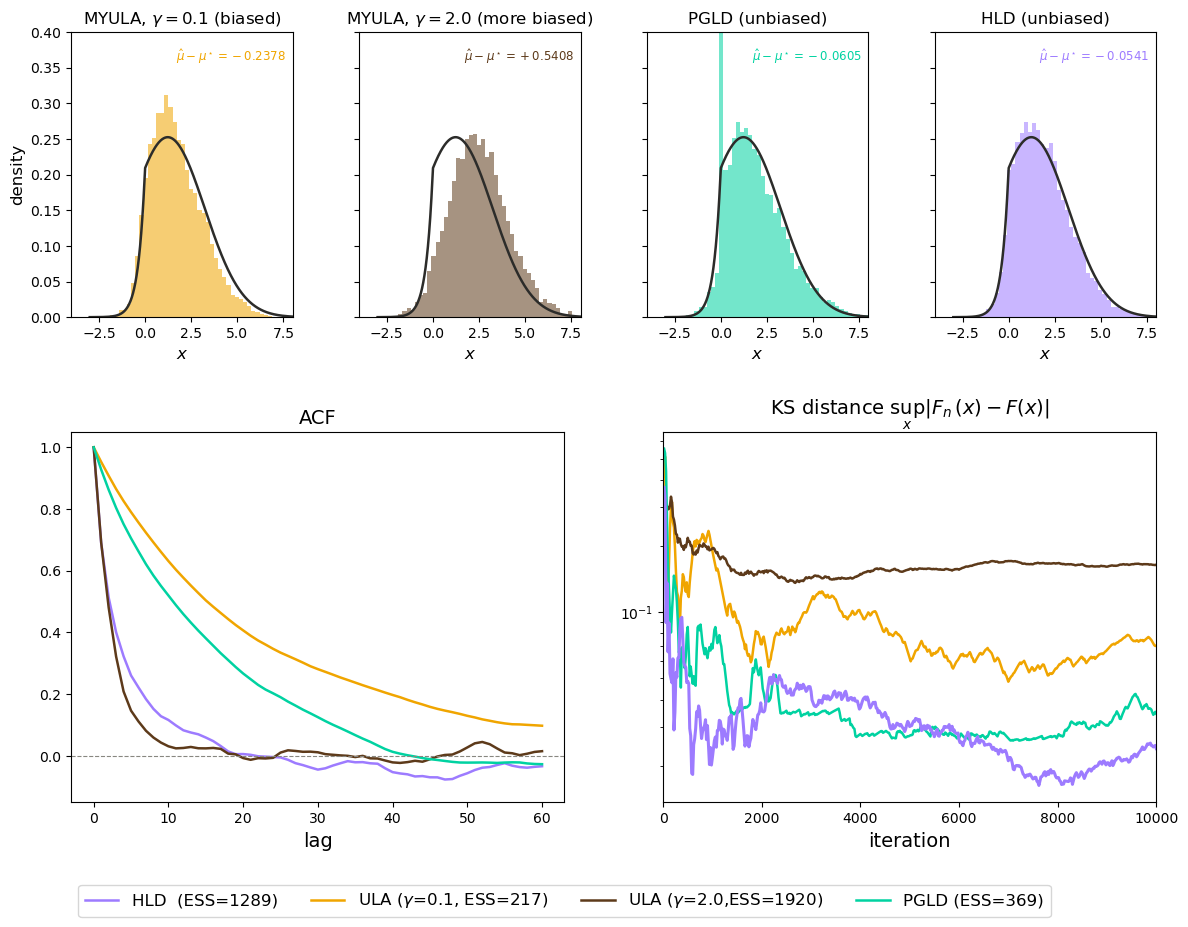

In [2]:

# ── palette ───────────────────────────────────────────────────────────────────

GRAY   = "#888780"
C_MLO  = "#F0A500"   # bright amber     — MYULA small γ  (light, warm)
C_MHI  = "#5D3A1A"   # dark brown       — MYULA large γ  (dark, same hue family)
C_SPG  = "#00D2A1"   # teal             — SPGLD
C_HLD  = "#9D7BFF"    # purple           — HLD
C_TRUE = "#2C2C2A"   # near-black       — true density


METHOD_STYLES = [
    (x_myula_lo, C_MLO, rf"MYULA $\gamma={gamma_lo}$"),
    (x_myula_hi, C_MHI, rf"MYULA $\gamma={gamma_hi}$"),
    (x_spgld,    C_SPG, "SPGLD"),
    (x_hld,      C_HLD, "HLD"),
]

# ── figure layout ─────────────────────────────────────────────────────────────
#
#  Row 0: [density: MYULA lo] [density: MYULA hi] [density: SPGLD] [density: HLD]
#  Row 1: [KS convergence , ACF]
#



fig = plt.figure(figsize=(14, 10))   
gs  = gridspec.GridSpec(
    2, 4,
    figure=fig,
    height_ratios=[1, 1.3],          
    hspace=0.35,
    wspace=0.30,
)

# replace the two ax_acf and ax_ks subplot calls with:
gs_bot = gridspec.GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=gs[1, :],
    wspace=0.2,                     # gap between ACF and KS panels
)



bins  = np.linspace(-3, 8, 50)
xlim  = (-4, 8)


titles = [
    rf"MYULA, $\gamma={gamma_lo}$ (biased)",
    rf"MYULA, $\gamma={gamma_hi}$ (more biased)",
    "PGLD (unbiased)",
    "HLD (unbiased)",
]
colors = [C_MLO, C_MHI, C_SPG, C_HLD]
chains = [x_myula_lo, x_myula_hi, x_spgld, x_hld]

# ── Row 0: density panels ─────────────────────────────────────────────────────

for col, (chain, color, title) in enumerate(zip(chains, colors, titles)):
    ax = fig.add_subplot(gs[0, col])
    ax.hist(chain, bins=bins, density=True,
            color=color, alpha=0.55, label="samples")
    ax.plot(xg, pi_x, color=C_TRUE, lw=1.8, label=r"true $\pi$")
    ax.set_xlim(xlim)
    ax.set_ylim([0,.4])
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(r"$x$", fontsize=12)
    if col == 0:
        ax.set_ylabel("density", fontsize=12)
    else:
        ax.set_yticklabels([])
    # if col == 3:
        # ax.legend(fontsize=9, loc="upper left")

    # annotate bias: mean of empirical CDF minus true CDF = signed area
    bias = np.mean(chain) - np.sum(xg * pi_x) * dx
    ax.text(0.97, 0.95, rf"$\hat\mu - \mu^\star = {bias:+.4f}$",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8.5, color=color)

# ── Row 1: ACF  (full width) ───────────────────────────────────────

# ax_acf = fig.add_subplot(gs[1, :2])
ax_acf = fig.add_subplot(gs_bot[0])
ax_ks  = fig.add_subplot(gs_bot[1])

# ax2 = fig.add_subplot(gs[0, 1])
lags = np.arange(len(acf_myula_lo))
ax_acf.plot(lags, acf_h, color=C_HLD, lw=1.8, label=f"HLD  (ESS={ess_h:.0f})")
ax_acf.plot(lags, acf_myula_lo, color=C_MLO,  lw=1.8, label=f"ULA ($\gamma$={gamma_lo:.1f}, ESS={ess_myula_lo:.0f})")
ax_acf.plot(lags, acf_myula_hi, color=C_MHI,  lw=1.8, label=f"ULA ($\gamma$={gamma_hi:.1f},ESS={ess_myula_hi:.0f})")
ax_acf.plot(lags, acf_spgld, color=C_SPG,  lw=1.8, label=f"PGLD (ESS={ess_spgld:.0f})")

ax_acf.axhline(0.0, color=GRAY, lw=0.8, ls="--")


ax_acf.set_xlabel("lag", fontsize=14)
# ax_acf.set_ylabel("ACF", fontsize=11)
ax_acf.set_title(r"ACF", fontsize=14)
ax_acf.set_ylim(-0.15, 1.05)


ax_acf.legend(loc='upper center', bbox_to_anchor=(1, -.2),
          fancybox=True, shadow=False, ncol=5,fontsize=12)


# ── Row 1: KS convergence (full width) ───────────────────────────────────────
  
ax_ks.semilogy(ts_mlo, ks_mlo, color=C_MLO, lw=1.8,
               label=rf"MYULA $\gamma={gamma_lo}$")
ax_ks.semilogy(ts_mhi, ks_mhi, color=C_MHI, lw=1.8,
               label=rf"MYULA $\gamma={gamma_hi}$")
ax_ks.semilogy(ts_spg, ks_spg, color=C_SPG, lw=1.8,
               label="PGLD")
ax_ks.semilogy(ts_hld, ks_hld, color=C_HLD, lw=2.2,
               label="HLD")
 
ax_ks.set_xlabel("iteration", fontsize=14)
ax_ks.set_title(r"KS distance $\sup_x |F_n(x) - F(x)|$", fontsize=14)
ax_ks.set_xlim(0, N_samples)



plt.savefig("comparison.pdf", bbox_inches="tight")
# plt.savefig("comparison.png", dpi=150, bbox_inches="tight")
# plt.show()
print("Saved comparison.pdf / .png")